# Klasifikimi i të Dhënave HAM10000 me Logistic Regression

Ky notebook përdor datasetin e filtruar HAM10000 për të trajnuar një model klasifikimi binar (`mel` vs `nv`) duke përdorur algoritmin **Logistic Regression** mbi metadata-n e pacientëve.

Procesi përfshin:
1️⃣ Ngarkimin dhe eksplorimin e datasetit.
2️⃣ Mbushjen e vlerave që mungojnë dhe kodimin e variablave kategorike.
3️⃣ Ndarjen e të dhënave në grupe trajnimi dhe testimi.
4️⃣ Standardizimin e veçorive.
5️⃣ Trajnimin e modelit Logistic Regression.
6️⃣ Vlerësimin e performancës së modelit.
7️⃣ Ruajtjen e modelit dhe scaler-it për përdorim të mëvonshëm.

## Importimi i Bibliotekave

In [10]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

## Përcaktimi i Folderave

In [11]:
BASE_DIR = os.getcwd()
METADATA_PATH = os.path.join(BASE_DIR, "HAM10000_metadata_filtered.csv")

print("Base directory:", BASE_DIR)

Base directory: C:\Users\Admin\Documents\GitHub\DermaScan\ham_dataset


## Ngarkimi dhe Pastrimi i Metadata

In [12]:
df = pd.read_csv(METADATA_PATH)
print(f"Numri total i rreshtave në metadata: {len(df)}")

# Mbushim vlerat që mungojnë për kolonën 'age' me mesataren
df["age"] = df["age"].fillna(df["age"].mean())
df.head()

Numri total i rreshtave në metadata: 2226


,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000871,ISIC_0025964,mel,histo,40.0,female,chest
1,HAM_0000871,ISIC_0030623,mel,histo,40.0,female,chest
2,HAM_0000040,ISIC_0027190,mel,histo,80.0,male,upper extremity
3,HAM_0005678,ISIC_0031023,mel,histo,60.0,male,chest
4,HAM_0005678,ISIC_0028086,mel,histo,60.0,male,chest


## Përzgjedhja dhe Kodimi i Veçorive

In [13]:
# Përzgjedhim veçoritë kryesore (duke përjashtuar ID-të unike dhe targetin)
feature_cols = ["age", "sex", "localization", "dx_type"]

# One-Hot Encoding për variablat kategorike
X = pd.get_dummies(df[feature_cols], drop_first=True)

# Kodojmë targetin (dx): nv -> 0, mel -> 1
y = df["dx"].map({"nv": 0, "mel": 1}).values

print("Veçoritë pas One-Hot Encoding:")
print(X.columns.tolist())
X.head()

Veçoritë pas One-Hot Encoding:
['age', 'sex_male', 'sex_unknown', 'localization_acral', 'localization_back', 'localization_chest', 'localization_ear', 'localization_face', 'localization_foot', 'localization_genital', 'localization_hand', 'localization_lower extremity', 'localization_neck', 'localization_scalp', 'localization_trunk', 'localization_unknown', 'localization_upper extremity', 'dx_type_follow_up', 'dx_type_histo']


,age,sex_male,sex_unknown,localization_acral,localization_back,localization_chest,localization_ear,localization_face,localization_foot,localization_genital,localization_hand,localization_lower extremity,localization_neck,localization_scalp,localization_trunk,localization_unknown,localization_upper extremity,dx_type_follow_up,dx_type_histo
0,40.0,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True
1,40.0,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True
2,80.0,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True
3,60.0,True,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True
4,60.0,True,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True


## Ndarja e të Dhënave në Trajnim dhe Testim

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Madhësia e Train Set: {X_train.shape[0]}")
print(f"Madhësia e Test Set: {X_test.shape[0]}")

Madhësia e Train Set: 1780
Madhësia e Test Set: 446


## Standardizimi i Veçorive

In [15]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Trajnimi i Modelit Logistic Regression

In [16]:
logreg = LogisticRegression(
    max_iter=1000,
    random_state=42
)
logreg.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


## Vlerësimi i Performancës së Modelit

Accuracy: 0.8071748878923767

Classification Report:

                precision    recall  f1-score   support

    nv (Nevus)       0.91      0.68      0.78       223
mel (Melanoma)       0.75      0.93      0.83       223

      accuracy                           0.81       446
     macro avg       0.83      0.81      0.80       446
  weighted avg       0.83      0.81      0.80       446



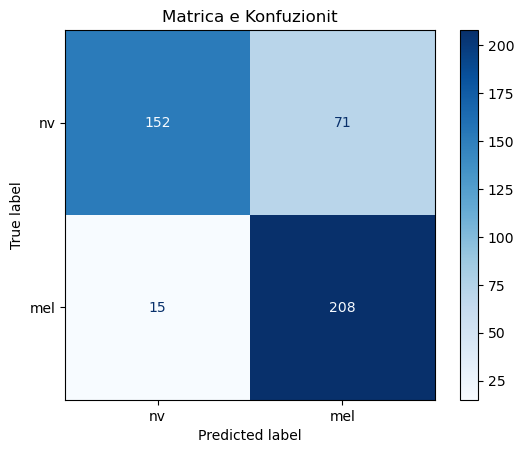

In [17]:
y_pred = logreg.predict(X_test_scaled)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=['nv (Nevus)', 'mel (Melanoma)']))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['nv', 'mel'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Matrica e Konfuzionit")
plt.show()

## Ruajtja e Modelit dhe Scaler-it

In [18]:
model_path = os.path.join(BASE_DIR, "logistic_regression_model.pkl")
scaler_path = os.path.join(BASE_DIR, "logistic_regression_scaler.pkl")
joblib.dump(logreg, model_path)
joblib.dump(scaler, scaler_path)
print(f"Modeli u ruajt me sukses në: {model_path}")
print(f"Scaler u ruajt me sukses në: {scaler_path}")

Modeli u ruajt me sukses në: C:\Users\Admin\Documents\GitHub\DermaScan\ham_dataset\logistic_regression_model.pkl
Scaler u ruajt me sukses në: C:\Users\Admin\Documents\GitHub\DermaScan\ham_dataset\logistic_regression_scaler.pkl
